In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import pandas as pd 
from skimage import io
import scipy.ndimage as ndi
from skimage import measure, morphology
from scipy.ndimage import gaussian_filter
from scipy.ndimage import center_of_mass
from adjustText import adjust_text
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
import json

### Load reference brain and area masks 

In [3]:
## Load in Mapzebrain reference brain 
ref_brain = io.imread(r'/Volumes/LaCie/area_masks/T_AVG_HuC.tif')

# Load in area masks 
areas = np.load(r'/Volumes/LaCie/area_masks/area_dict_updated.npy',allow_pickle='TRUE').item()

# Load in area dictionary with name and shorthand 
with open("/Volumes/LaCie/larval_HuC/imaging/brain_map_values/area_shorthand_dict.json", "r") as f:
    area_shorthand_dict = json.load(f)
    
    
# load in additional area masks is needed 
nMLF = io.imread('/Volumes/LaCie/area_masks/area_masks_mapzebrain/nMLF.tiff')
areas['nMLF'] = nMLF
keys = areas.keys() # needed in plotting code 

NameError: name 'area' is not defined

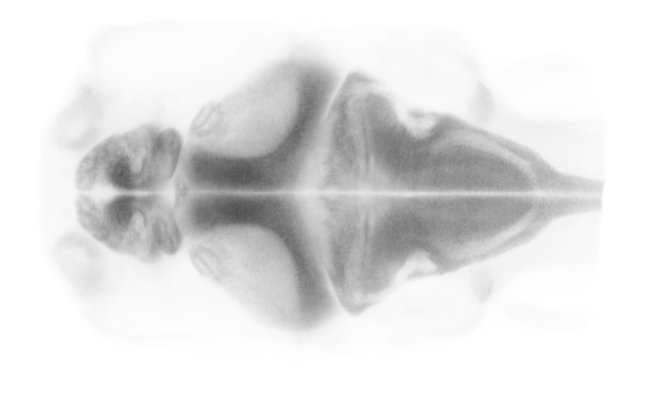

In [5]:
## Visualise the location of A-P slices to choose slice position 
fig, ax = plt.subplots(figsize=(10, 5))
proj_horizontal = np.nanmean(ref_brain, axis=0)
proj_horizontal = np.rot90(proj_horizontal, k=1)  # 90° CCW
ax.imshow(proj_horizontal, cmap='gray_r', alpha=0.7, origin='lower')
ax.axis('off')

slice_index = area.shape[2] // 2

# Because of rotation, what was previously x now becomes y
y1 = slice_index - 68
y2 = slice_index - 10

# Use horizontal lines
ax.axhline(y=y1, color='black', linestyle='-', linewidth=3)
ax.axhline(y=y2, color='black', linestyle='-', linewidth=3)

# plt.savefig(f"/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/Brain_map_slices_10_68.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

### Build brain map of areas without data visulaisation 

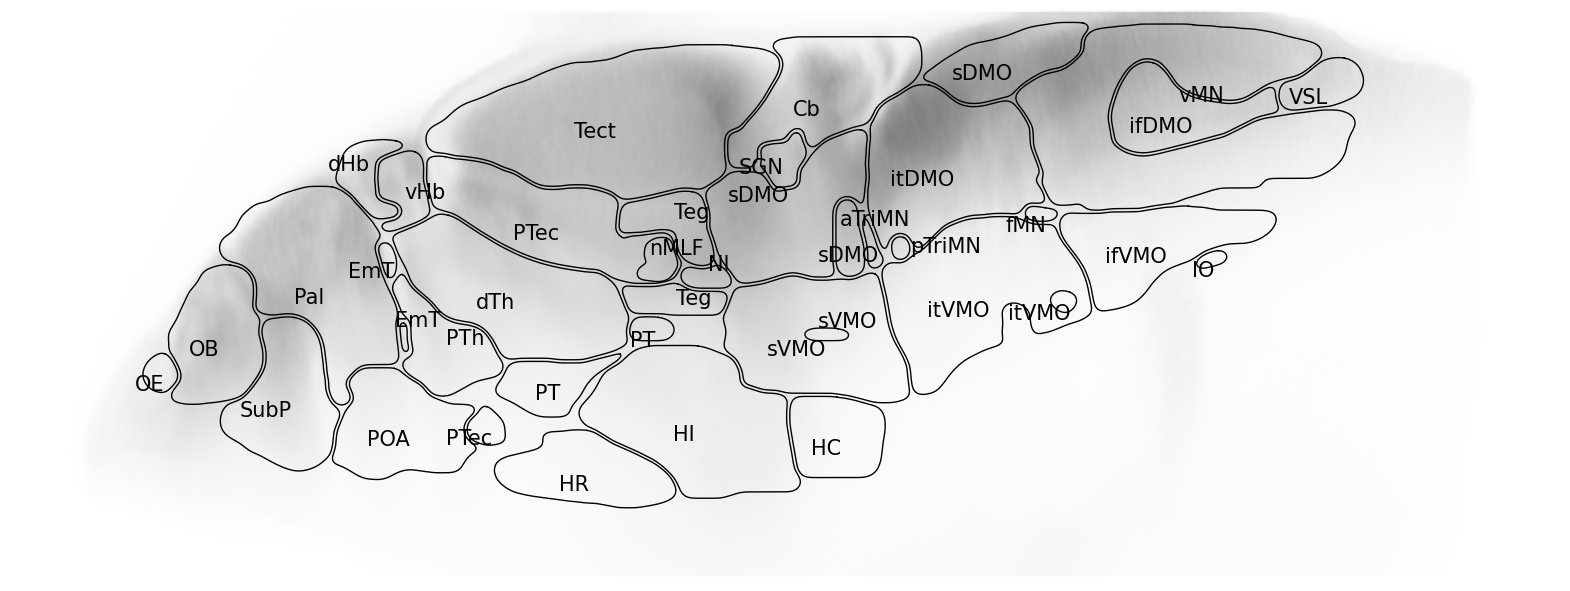

In [6]:
fig, ax = plt.subplots(figsize=(20, 15))
ax.imshow(np.nanmean(ref_brain, 2), cmap='gray_r', alpha=.5, origin='lower') 
ax.axis('off')
text_objects = []

for brain_area in keys:
    area = areas[brain_area]
    slice_index = area.shape[2] // 2
    area_2d = area[:, :, slice_index-68] # Here you can change the slice index  

    # Step 1: Apply morphological erosion to avoid overlap
    eroded_area = morphology.binary_erosion(area_2d, morphology.disk(1))  
    
    # Step 2: Apply Gaussian smoothing to make the shape of the area more rounded
    smoothed_slice = gaussian_filter(eroded_area.astype(float), sigma=3)

    # Step 3: Extract contours from the smoothed area
    area_contour = measure.find_contours(smoothed_slice, level=0.5)
    shorthand_name = area_shorthand_dict.get(brain_area, brain_area) # replace area names with shorthand
    
    # Step 4: Simplify and plot the contours
    for contour in area_contour:
        # Extract x and y coordinates
        x, y = contour[:, 1], contour[:, 0]
        # Plot the smoothed and eroded contour as a black line
        ax.plot(x, y, color='black', linewidth=1)
        
        # Use the centroid of the contour as the label position
        centroid_x = np.mean(x)
        centroid_y = np.mean(y)
       
        # Create a text object for the label
        text_obj = ax.text(centroid_x, centroid_y, shorthand_name, color='black', fontsize=15, ha='center', va='center')
        text_objects.append(text_obj)

# Automatically adjust text labels to help reduce poverlap
adjust_text(text_objects, ax=ax, expand_text=(1.2, 1.2))

plt.show()

### build brain map with data visulisation 

In [22]:
## Load in the values you want to add to the brain plot 
## dataframe with columns ['area_names'], [values] (of the whatever analysis), ['p_values'] (p value is optional based on the analysis) 

area_values_df = pd.read_csv("/Volumes/LaCie/larval_HuC/imaging/7dpf_straight_bout_sig_0.3.csv")
## remove not_assigned value 
area_value_df = area_values_df[area_values_df['area_names'] != 'not_assigned']

In [23]:
area_value_df['values'].max()

np.float64(0.0571428571428571)

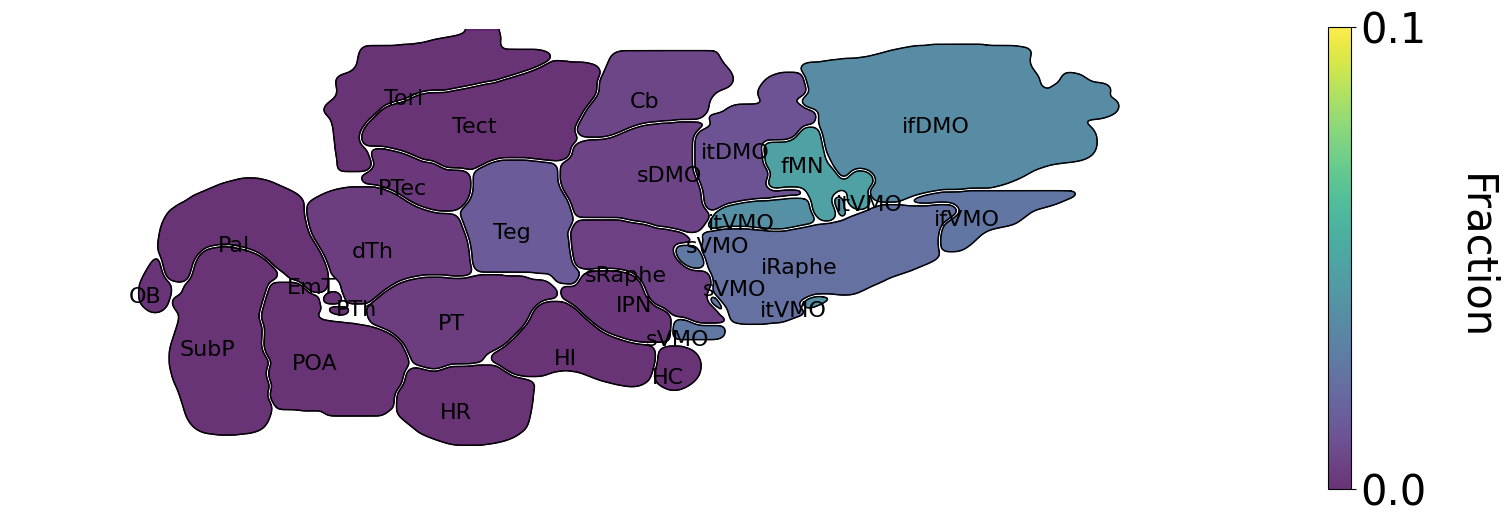

In [29]:
values = area_values_df["values"].values

## load a color map
norm = colors.Normalize(vmin=0, vmax=0.1) # set min and max for the LUT 
cmap =  cm.viridis #cm.bwr 

## Or build your own color map: 
vmax=np.max(values)
# norm = colors.PowerNorm(gamma=0.5, vmin=0.01, vmax=vmax) 
# cmap_stim = LinearSegmentedColormap.from_list('white_to-color', ['white', 'magenta'])

# cmap = cmap_stim

cmap.set_bad(color='gray')  # if there is no data default to gray color 
fig, ax = plt.subplots(figsize=(20, 20))
ax.imshow(np.nanmean(ref_brain, 2), cmap='gray_r', alpha=.001, origin='lower') 
ax.axis('off')
text_objects = []

# Iterate over each brain area and plot with the corresponding color
for brain_area in keys:
    area = areas[brain_area]
    slice_index = area.shape[2] // 2
    area_2d = area[:, :, slice_index -10]   # Here you can adjust the slice index; 10 ("medial") 68 ("lateral")
    
    # Step 1: Apply morphological erosion to avoid overlap
    eroded_area = morphology.binary_erosion(area_2d, morphology.disk(1))

    # Step 2: Apply Gaussian smoothing to make the shape more rounded
    smoothed_slice = gaussian_filter(eroded_area.astype(float), sigma=3)

    # Step 3: Extract contours from the smoothed area
    area_contour = measure.find_contours(smoothed_slice, level=0.5)
    
    # Get the value for the current brain area and map it to a color
    if brain_area in area_values_df["area_names"].values:
        area_value = area_values_df.loc[area_values_df["area_names"] == brain_area, "values"].values[0]
        p_value = area_values_df.loc[area_values_df["area_names"] == brain_area, "p_value"].values[0]
    else:
        area_value = np.nan  # Assign a default value of 0 if the area is not found
        p_value = 1  # Default p-value to 1 (not significant)
        print(f"Info: {brain_area} not found in DataFrame. Assigning value 0 and p-value 1.")
    
    area_color = cmap(norm(area_value))
    
    # Get the shorthand name for the brain area
    shorthand_name = area_shorthand_dict.get(brain_area, brain_area)  # Use the full name if no shorthand is found

    # Plot the filled area and the contour
    for contour in area_contour:
        x, y = contour[:, 1], contour[:, 0]

        # Fill the area with the mapped color
        ax.fill(x, y, color=area_color, alpha=0.8)
      
        # Use the centroid of the contour as the label position
        centroid_x = np.mean(x)
        centroid_y = np.mean(y)
        
        # Create a text object for the label
        text_color = 'black' #if area_value >= 0.02 else 'white'
        text_obj = ax.text(centroid_x, centroid_y, shorthand_name, color = text_color , fontsize=16, ha='center', va='center')
        text_objects.append(text_obj)
      
        ax.plot(x, y, color= 'black', linewidth=1)
        
        ## Set the outline thickness and color based on p-value
        outline_color = 'orange' # if signfificant outline with this color 
        outline_width = 3 if p_value < 0.05 else 0.5
        ax.plot(x, y, color=outline_color if p_value < 0.05 else 'black', linewidth=outline_width)

#Add a colorbar for reference
adjust_text(text_objects, ax=ax, expand_text=(1.2, 1.2))  # Adjusts text positions to avoid overlap
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.3, alpha=0.8)

# Format the colorbar tick labels to 2 decimal places
formatter = FuncFormatter(lambda x, _: f"{x:.1f}")  # Format to 2 decimal places
cbar.ax.yaxis.set_major_formatter(formatter)
cbar.set_ticks([0,0.1])
cbar.set_label("Fraction", rotation=270, labelpad=50, fontsize=30)
cbar.ax.tick_params(labelsize=30)

## Save plot 
plt.savefig(f"/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/7dpf_straight_bout_sig_pfdr_>0.3_medial_own_cmap.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()